In [34]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import pickle
import pathlib

sns.set_style("whitegrid")
sns.set_context("paper")
sns.set_palette("deep", color_codes=True)


In [35]:
energy_files = list(pathlib.Path("extraction/alt_energies").rglob("*.pkl"))
file_to_qubit_count_mapping = {}
for file in energy_files:
    file_stem = str(file.stem)
    str_qubit_count = file.as_posix().split("/")[-2]
    try:
        qubit_count = int(str_qubit_count)
        file_to_qubit_count_mapping[file_stem] = qubit_count
    except ValueError:
        print(f"Warning: Could not convert '{str_qubit_count}' to an integer for file {file_stem}. Skipping this file.")

In [36]:
def get_files_by_folders(results_folders):
    result_paths = []
    for results_folder in results_folders:
        paths = list(pathlib.Path(f"qaoa/{results_folder}").glob("*.npz"))
        result_paths.extend(paths)

    return {path.as_posix().split("/")[-1].split(".")[0]: {"path": path} for path in result_paths}
warm_start_files = get_files_by_folders(["qaoa_runs_5-14_batch1", "qaoa_runs_5-14_batch2"])

In [37]:
def generate_df_from_files(result_files, file_to_qubit_count_mapping, target_confidence=0.9999):
    data_keys = ["cost_history", "target_probs", "target_indices", "best_target_index", "conformation_map"]

    for name, data in result_files.items():
        with open(data["path"], 'rb') as f:
            saved_results = np.load(f, allow_pickle=True)
            result_files[name]["data"] = {key: saved_results[key] for key in data_keys}

        result_files[name]["protein"] = name.split("_")[0]
        result_files[name]["start_residue"] = int(name.split("_")[1])
        result_files[name]["end_residue"] = int(name.split("_")[2])
        result_files[name]["rotamer_count"] = int(name.split("_")[3])
        result_files[name]["qaoa_layers"] = int(name.split("_")[4])

        result_files[name]["subsection"] = f"{result_files[name]['start_residue']}-{result_files[name]['end_residue']}"
        result_files[name]["subsection_length"] = result_files[name]["end_residue"] - result_files[name]["start_residue"] + 1

        name_without_layers = "_".join(name.split("_")[:-2])
        if name_without_layers in file_to_qubit_count_mapping:
            result_files[name]["num_qubits"] = file_to_qubit_count_mapping[name_without_layers]
        else:
            print(f"Warning: No qubit mapping found for {name_without_layers}. Setting num_qubits to None.")
            result_files[name]["num_qubits"] = None

    target_probs_records = []
    for name, data in result_files.items():
    # if not name.startswith("5PTI_18_22"): continue

        target_probs = result_files[name]["data"]['target_probs']
        # print("Shape of target_probs:", target_probs.shape)  # Should be (30, 16)

        # Sum across the 16 conformations for each seed
        summed_probs = target_probs.sum(axis=1)  # Shape becomes (30,)
        # print("Shape after summing across conformations:", summed_probs.shape)


        # Create a record for each seed with its summed probability
        for seed_idx, summed_prob in enumerate(summed_probs):
            if int(summed_prob) == 1: shots_for_target_prob = 1
            else: shots_for_target_prob = np.ceil(np.log(1 - target_confidence) / np.log(1 - summed_prob))
            record = {
                'protein': result_files[name]['protein'],
                'subsection': result_files[name]['subsection'],
                'subsection_length': result_files[name]['subsection_length'],
                'rotamer_count': result_files[name]['rotamer_count'],
                'qaoa_layers': result_files[name]['qaoa_layers'],
                'num_qubits': result_files[name]['num_qubits'],
                'seed': seed_idx,
                'target_prob': summed_prob,  # This is now the sum across all 16 conformations
                'shots_for_target_prob': shots_for_target_prob
            }
            target_probs_records.append(record)

    # Create dataframe from records
    return pd.DataFrame(target_probs_records)

In [38]:
warm_start_df = generate_df_from_files(warm_start_files, file_to_qubit_count_mapping)

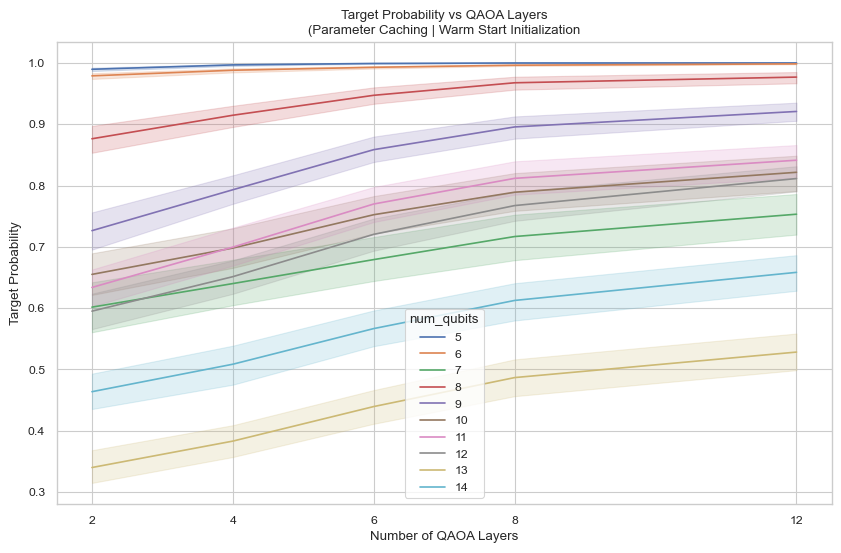

In [39]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=warm_start_df,
             x="qaoa_layers", y="target_prob",
             hue='num_qubits', #style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', as_cmap=True,
                                       n_colors=warm_start_df['num_qubits'].nunique()),
             ax=ax)

ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/warm_start_probabilities.svg", dpi=300, bbox_inches='tight')

In [40]:
cold_start_files = get_files_by_folders(["qaoa_results_8_cold_start"])
cold_start_df = generate_df_from_files(cold_start_files, file_to_qubit_count_mapping)

warm_start_files2 = get_files_by_folders(["qaoa_runs_5-14_batch1"])
warm_start_df2 = generate_df_from_files(warm_start_files2, file_to_qubit_count_mapping)

/var/folders/01/t57whxgn07b0dg1mhrwgv0kw0000gn/T/ipykernel_71524/3411006095.py:3: UserWarning: The palette list has more values (10) than needed (3), which may not be intended.
  sns.lineplot(data=cold_start_df,


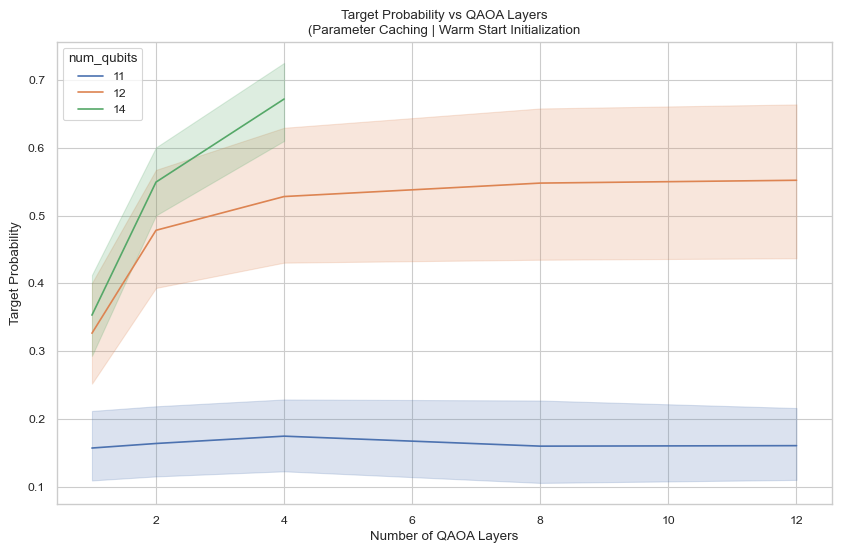

In [41]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data=cold_start_df,
             x="qaoa_layers", y="target_prob",
             hue='num_qubits', #style='num_qubits',
             markers=False,
             palette=sns.color_palette('deep', as_cmap=True,
                                       n_colors=cold_start_df['num_qubits'].nunique()),
             ax=ax)

# ax.set_xticks([2, 4, 6, 8, 12])

ax.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization")
ax.set_xlabel("Number of QAOA Layers")
ax.set_ylabel("Target Probability")

plt.savefig(f"plots/cold_start_probabilities.svg", dpi=300, bbox_inches='tight')

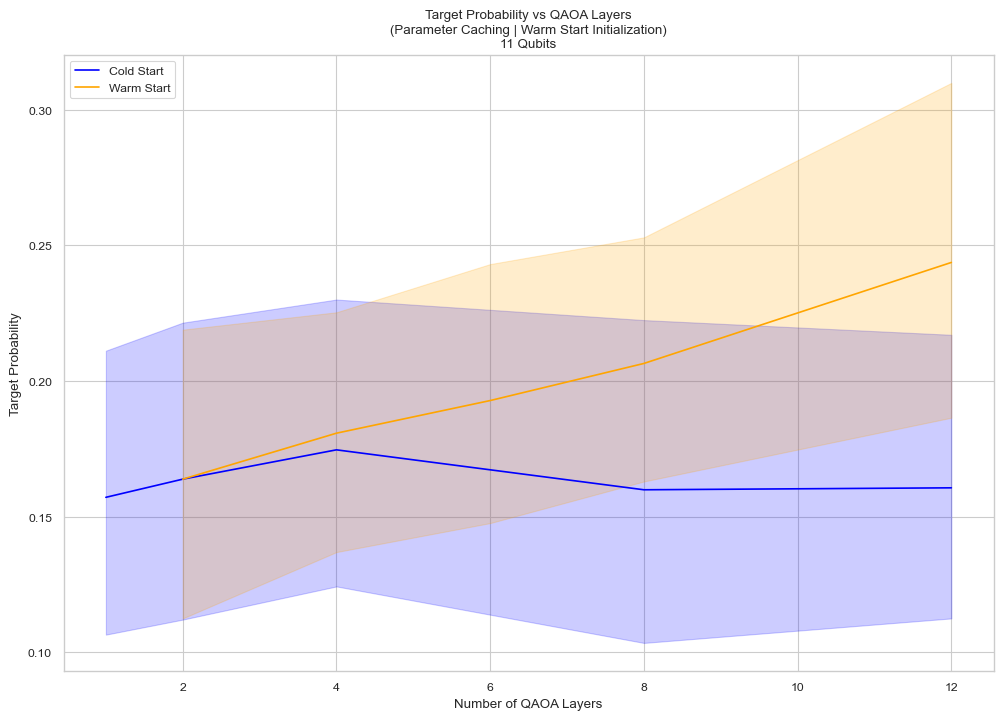

In [60]:
# 11 subsection, = 18-22, length=5, rotmamer_count=4

# Plot cold start vs warm start on the same plot
# One subplot for 11 qubits, one subplot for 12 qubits
cold_start_subset_11 = cold_start_df[cold_start_df['num_qubits'] == 11]

# Filter warm start more aggressively to match the cold start subsections and rotamer counts
warm_start_subset_11 = warm_start_df[warm_start_df['num_qubits'] == 11]
warm_start_subset_11 = warm_start_subset_11[warm_start_subset_11['subsection'] == '18-22']
warm_start_subset_11 = warm_start_subset_11[warm_start_subset_11['rotamer_count'] == 4]

fig, axes = plt.subplots(1, 1, figsize=(12, 8), sharey=True)

sns.lineplot(data=cold_start_subset_11,
             x="qaoa_layers", y="target_prob",
             color='blue',
             markers=True,
             label='Cold Start',
             ax=axes, legend=True)

sns.lineplot(data=warm_start_subset_11,
             x="qaoa_layers", y="target_prob",
            color='orange',
            label='Warm Start',
             ax=axes, legend=True)

axes.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization)\n11 Qubits")
axes.set_xlabel("Number of QAOA Layers")
axes.set_ylabel("Target Probability")

plt.savefig(f"plots/cold_vs_warm_start_probabilities.svg", dpi=300, bbox_inches='tight')


Text(0.5, 1.0, 'Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization)\n11 Qubits')

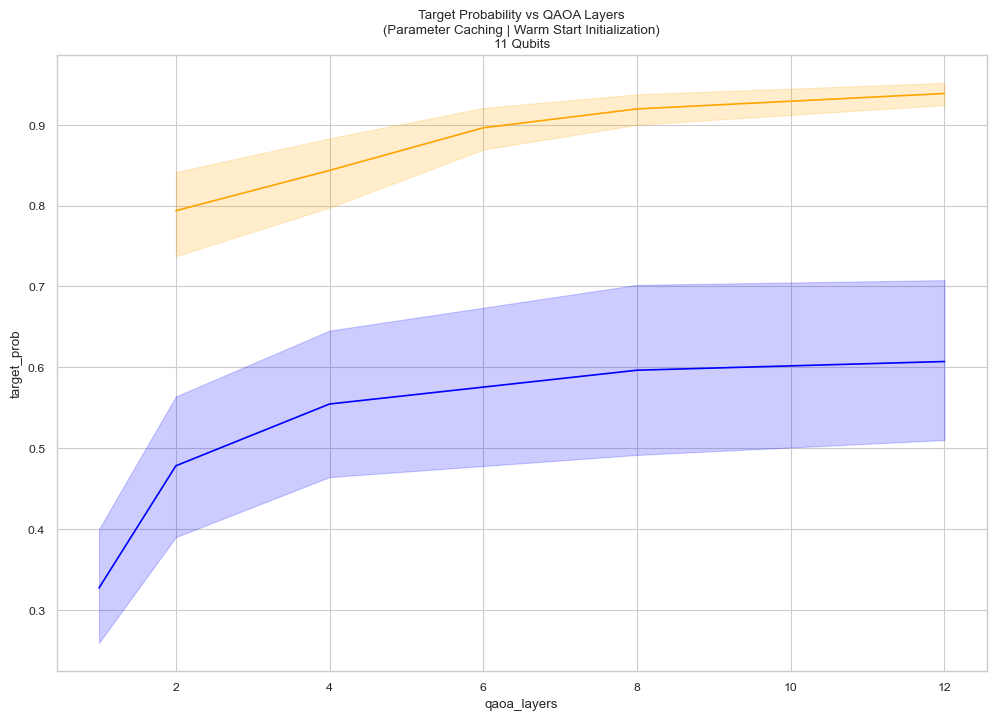

In [58]:
cold_start_files2 = get_files_by_folders(["qaoa_results_4"])
cold_start_df2 = generate_df_from_files(cold_start_files2, file_to_qubit_count_mapping)

cold_start_2_11 = cold_start_df2[cold_start_df2['num_qubits'] == 11]
cold_start_2_12 = cold_start_df2[cold_start_df2['num_qubits'] == 12]

warm_start_2_11 = warm_start_df[warm_start_df['num_qubits'] == 11]
warm_start_2_11 = warm_start_2_11[warm_start_2_11['subsection'] == '18-22']
warm_start_2_11 = warm_start_2_11[warm_start_2_11['rotamer_count'] == 4]

warm_start_2_12 = warm_start_df[warm_start_df['num_qubits'] == 12]
warm_start_2_12 = warm_start_2_12[warm_start_2_12['subsection'] == '22-28']
warm_start_2_12 = warm_start_2_12[warm_start_2_12['rotamer_count'] == 4]

fig, axes = plt.subplots(1, 1, figsize=(12, 8), sharey=True)

sns.lineplot(data=cold_start_2_12,
             x="qaoa_layers", y="target_prob",
             color='blue',
             markers=True,
             ax=axes, legend=False)

sns.lineplot(data=warm_start_2_12,
             x="qaoa_layers", y="target_prob",
            color='orange',
             ax=axes, legend=False)

axes.set_title("Target Probability vs QAOA Layers\n(Parameter Caching | Warm Start Initialization)\n11 Qubits")


In [56]:
cold_start_2_12

,protein,subsection,subsection_length,rotamer_count,qaoa_layers,num_qubits,seed,target_prob,shots_for_target_prob
0,5PTI,22-28,7,4,8,12,0,0.951118,4.0
1,5PTI,22-28,7,4,8,12,1,0.971245,3.0
2,5PTI,22-28,7,4,8,12,2,0.994446,2.0
3,5PTI,22-28,7,4,8,12,3,0.971294,3.0
4,5PTI,22-28,7,4,8,12,4,0.994334,2.0
...,...,...,...,...,...,...,...,...,...
565,5PTI,18-22,5,5,8,12,25,0.028451,320.0
566,5PTI,18-22,5,5,8,12,26,0.113709,77.0
567,5PTI,18-22,5,5,8,12,27,0.103725,85.0
568,5PTI,18-22,5,5,8,12,28,0.007382,1244.0
